In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Task 1: Data Cleaning & Preparation

In [4]:
df = pd.read_csv('RELIANCE.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df['2020-01-01':]
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 332 entries, 2020-01-01 to 2021-04-30
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Symbol              332 non-null    str    
 1   Series              332 non-null    str    
 2   Prev Close          332 non-null    float64
 3   Open                332 non-null    float64
 4   High                332 non-null    float64
 5   Low                 332 non-null    float64
 6   Last                332 non-null    float64
 7   Close               332 non-null    float64
 8   VWAP                332 non-null    float64
 9   Volume              332 non-null    int64  
 10  Turnover            332 non-null    float64
 11  Trades              332 non-null    float64
 12  Deliverable Volume  332 non-null    float64
 13  %Deliverble         332 non-null    float64
dtypes: float64(11), int64(1), str(2)
memory usage: 38.9 KB


#### Task 2: Trend Analysis (The "Golden Cross")
Investors look for "Buy" signals. A famous one is the Golden Cross, which happens when the short-term average (50-day) crosses above the long-term average (200-day).

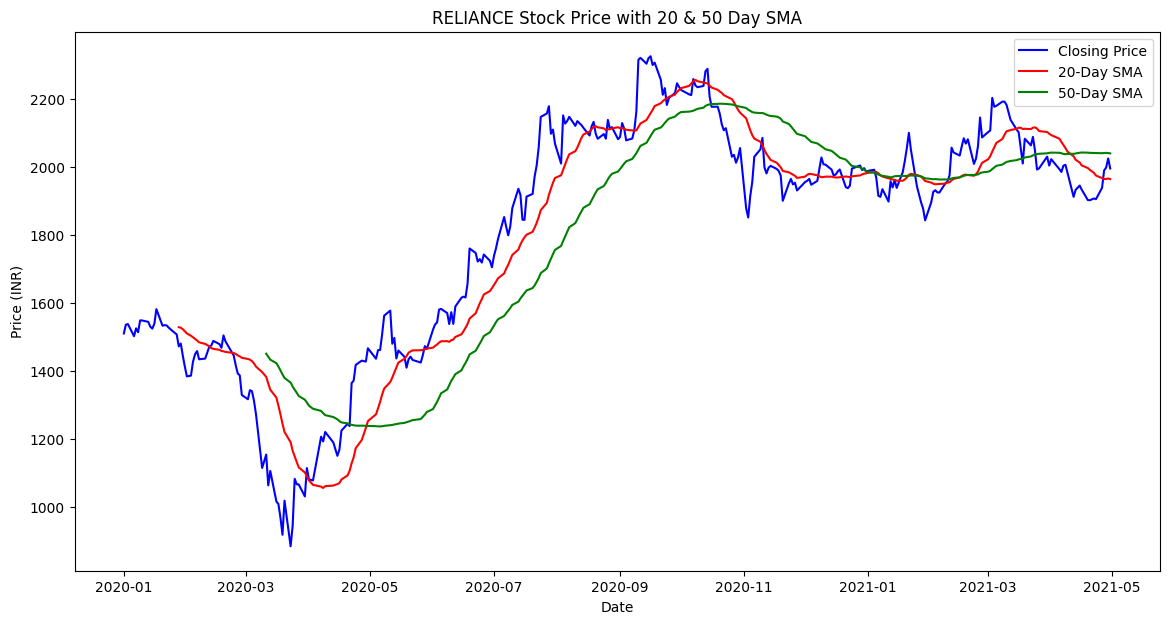

In [21]:
sma20 = df['Close'].rolling(window=20).mean()
sma50 = df['Close'].rolling(window=50).mean()
plt.figure(figsize=(14,7))
plt.plot( df['Close'].index, df['Close'].values, label='Closing Price', color='blue')
plt.plot(sma20.index, sma20.values, label='20-Day SMA', color='red')
plt.plot(sma50.index, sma50.values, label='50-Day SMA', color='green')
plt.title('RELIANCE Stock Price with 20 & 50 Day SMA')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

#### Task 3: Risk Analysis (Volatility)
 Calculate the Daily Return (percentage change).

``` 
Insight:
A narrow, tall bell curve = Low Risk (Stable).
A wide, flat curve = High Risk (Volatile).
```

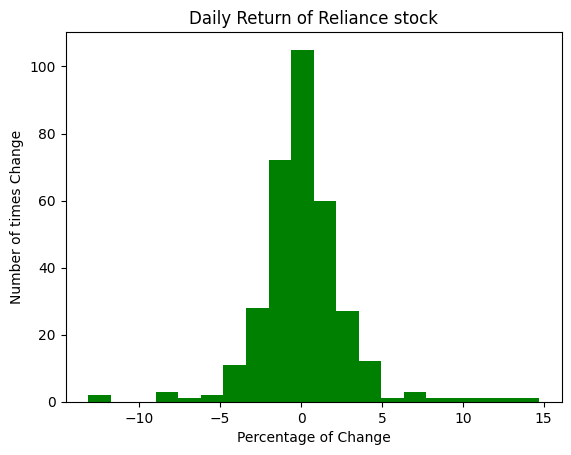

In [37]:
df['Daily_Return'] =(( df['Close'] -  df['Close'].shift(periods=1)) /  (df['Close'].shift(periods=1)* 0.01)).fillna(0)


plt.hist(df['Daily_Return'],bins=20,color='g',label='histogram')
plt.xlabel("Percentage of Change")
plt.ylabel("Number of times Change")
plt.title("Daily Return of Reliance stock")
plt.show()

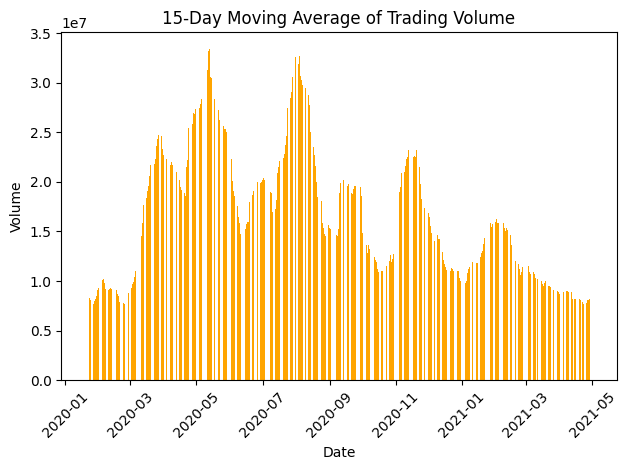

,Volume,Daily_Return
Date,,
2020-04-22,65230894,10.203257
2020-09-10,64751766,7.062715
2020-07-15,64458598,-3.808033
2020-04-24,61711388,3.362754
2020-07-24,55656793,4.293420


In [99]:
# Display top 5 rows sorted by Volume (highest volume days)

plt.bar(df["Volume"].index, df["Volume"].rolling(window=15).mean(), color='orange')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('15-Day Moving Average of Trading Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
df_sorted=df.sort_values('Volume', ascending=False).head(5)
df_sorted[['Volume','Daily_Return']]




Task 5: Investment Simulation (The "What If")
This adds a fun "reality" element to your project.

- **Action:** Create a variable `initial_investment = 100000` (1 Lakh INR).
- **Logic:** Assume you bought the stock on the very first day of your dataset. Calculate how much that ₹1 Lakh would be worth today based on the final closing price.
- **Output:** Print: *"If you invested ₹1 Lakh in Reliance in 2015, it would be worth ₹X today."*


In [112]:
budget =100000 
current_price=budget
i=0
for price in df['Close']:
    if current_price < price:
        break
    initial_price = df['Close'].iloc[i]
    current_price = current_price - initial_price
    i += 1

final_price = df['Close'].iloc[-1]
final_value = i * final_price
print(f"If you invested ₹1 Lakh in Reliance in 2020, it would be worth ₹{final_value:.2f} today.\n Total Profit: ₹{final_value - 100000:.2f}\n Total Return: {(final_value - budget)/(budget*0.01):.2f}%\n Total Years: {i/252:.2f} years\n Total Stocks Bought: {i}")

If you invested ₹1 Lakh in Reliance in 2020, it would be worth ₹149587.50 today.
 Total Profit: ₹49587.50
 Total Return: 49.59%
 Total Years: 0.30 years
 Total Stocks Bought: 75
